In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from flonacomldft.utils.io_utils import (
    get_path,
    get_project_path,
    load_pickle_file,
    load_csv_file,
)

from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.plots import (
    set_plot_sequential_data,
    plot_energy_surface,
    plot_energy_histogram,
)

from flonacomldft.utils.data_processing import load_datasets

from flonacomldft.utils.diagnostics import (
    R_hat,
    Target_Log_Prob,
)

#from flonacomldft.free_energy_computations import (
#    compute_TFP_logratio, compute_deepBAR_logratio,
#    compute_TFP, compute_BAR
#)

import matplotlib.pylab as pylab

size=16
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [3]:
EMT_DATA_PATH = get_path()+'/emt_andersen/'

## 1. EMT calculations

### 1.a MD configuration on FES and MLP dataset on FES

In [4]:
# load md data, train and test
xs_flow_emt = {key: load_csv_file('is1_flow_{:s}.csv'.format(key), EMT_DATA_PATH + 'datasets') 
            for key in ['train', 'test']}

xs_mlp_emt = {key: load_csv_file('is1_mlp_{:s}.csv'.format(key), EMT_DATA_PATH + 'datasets') 
            for key in ['train', 'test']}

In [5]:
# collective variables
cvs_flow_emt = {key: xs_flow_emt[key][:, -2:] for key in xs_flow_emt.keys()}
cvs_mlp_emt = {key: xs_mlp_emt[key][:, -2:] for key in xs_mlp_emt.keys()}

In [6]:
xs_flow_emt = load_datasets(md='emt_andersen', isomer_id=1, name='flow', real_centered=True, temperature=350)
xs_mlp_emt = load_datasets(md='emt_andersen', isomer_id=1, name='mlp', real_centered=True, temperature=350)

No figure provided. Cannot add colorbar.


Text(0.5, 0.98, 'Collective variables on energy surface (EMT)')

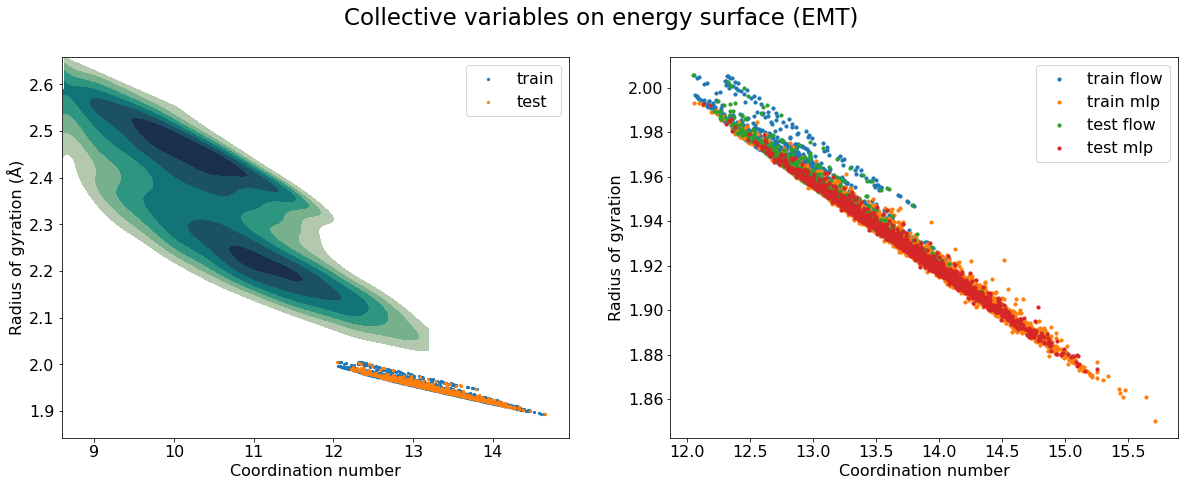

In [7]:
# plot fes

fig, axs = plt.subplots(1, 2, figsize=(20,7))

plot_energy_surface(ax=axs[0])

for key in cvs_flow_emt.keys():

    axs[0].scatter(cvs_flow_emt[key][:, 0], cvs_flow_emt[key][:, 1], s=5, label=key)

    for cvs, label in zip([cvs_flow_emt, cvs_mlp_emt], ['flow', 'mlp']):
        axs[1].scatter(cvs[key][:, 0], cvs[key][:, 1], s=10, label=key +' '+ label)

    axs[1].set_xlabel('Coordination number')
    axs[1].set_ylabel('Radius of gyration')

axs[0].legend()
axs[1].legend()

fig.suptitle('Collective variables on energy surface (EMT)', fontsize=23)

### 1.b MLP model for EMT

In [8]:
dict_mlp_model_emt = load_pickle_file('dict_mlp_model_is1.pkl', EMT_DATA_PATH + 'models')

In [9]:
emt_model = dict_mlp_model_emt['model']
losses = { key: torch.tensor(dict_mlp_model_emt[key+'_loss']) for key in ['train', 'test']}

us_flow_pred = {key: emt_model(xs_flow_emt[key][:, :12]).detach()
                for key in xs_flow_emt.keys()}

us_mlp_pred = {key: emt_model(xs_mlp_emt[key][:, :12]).detach()
                for key in xs_mlp_emt.keys()}

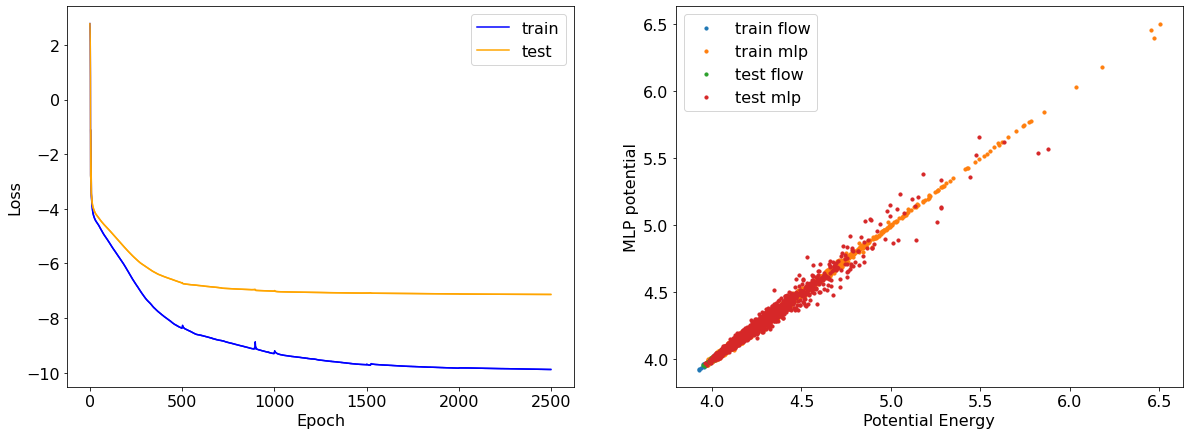

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(20,7))

colors = ['Blue', 'Orange']

for i, key in enumerate(us_flow_pred.keys()):
    set_plot_sequential_data(losses[key].log(), label=key, ax=axs[0], alpha=1, color=colors[i])

axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')

axs[0].legend()


for key in us_flow_pred.keys():
    for xs, us, label in zip([xs_flow_emt, xs_mlp_emt], [us_flow_pred, us_mlp_pred], ['flow', 'mlp']):
        axs[1].scatter(xs[key][:, 12].detach(), us[key].flatten().detach(), s=10, label=key +' '+ label)

axs[1].set_xlabel('Potential Energy')
axs[1].set_ylabel('MLP potential')

axs[1].legend()

### 1.c Adaptive EMT with and without MLP

In [6]:
EMT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-emt/'
DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/'

In [12]:
adaptive_emt_path = ['1-adaptive/results_adaptive_is1_28665681/adaptive_sampling_is1_28665681.pkl']
adaptive_emt_mlp_path = ['2-adaptive-mlp/results_adaptive_is1_28690164/adaptive_sampling_is1_28690164.pkl']

In [13]:
adaptives_mcmc_emt = [load_pickle_file(adaptive_file, EMT_SIMS_PATH) for adaptive_file in adaptive_emt_path]
adaptives_mcmc_emt_mlp = [load_pickle_file(adaptive_file, EMT_SIMS_PATH) for adaptive_file in adaptive_emt_mlp_path]

### 1.c.i MLP loss

In [14]:
losses_mlp_train = [torch.cat([torch.tensor(adaptives_mcmc_emt_mlp[i]['dict_mlps_training'][j][0]['train_loss'])
                            for j in range(1, len(adaptives_mcmc_emt_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(1)]

losses_mlp_test = [torch.cat([torch.tensor(adaptives_mcmc_emt_mlp[i]['dict_mlps_training'][j][0]['test_loss'])
                            for j in range(1, len(adaptives_mcmc_emt_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(1)]

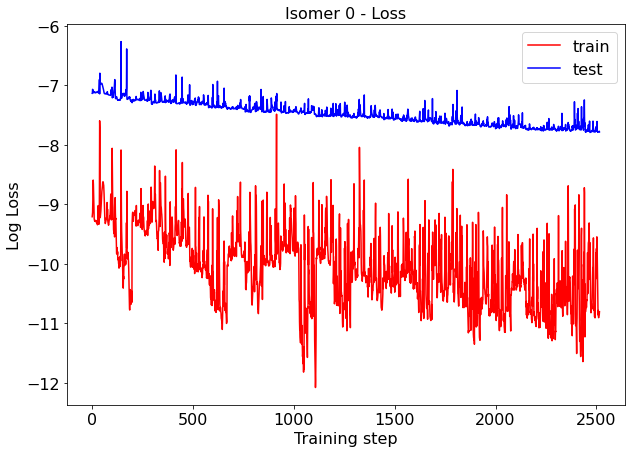

In [15]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

axs = [axs]

for i in range(len(losses_mlp_train)):
    set_plot_sequential_data(torch.log(losses_mlp_train[i]), ax=axs[i], color='red', label='train', alpha=1, avg=False)
    set_plot_sequential_data(torch.log(losses_mlp_test[i]), ax=axs[i], color='blue', label='test', alpha=1, avg=False)

    axs[i].set_xlabel('Training step')
    axs[i].set_ylabel('Log Loss')
    axs[i].set_title(f'Isomer {i} - Loss')

    axs[i].legend()

### 1.c.ii Flow loss

In [16]:
losses_emt = [torch.cat([adaptives_mcmc_emt[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_emt[i]['dict_flows_training']))
                            ]) 
                            for i in range(1)]
                          
losses_emt_mlp = [torch.cat([adaptives_mcmc_emt_mlp[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_emt_mlp[i]['dict_flows_training']))
                            ])
                            for i in range(1)]

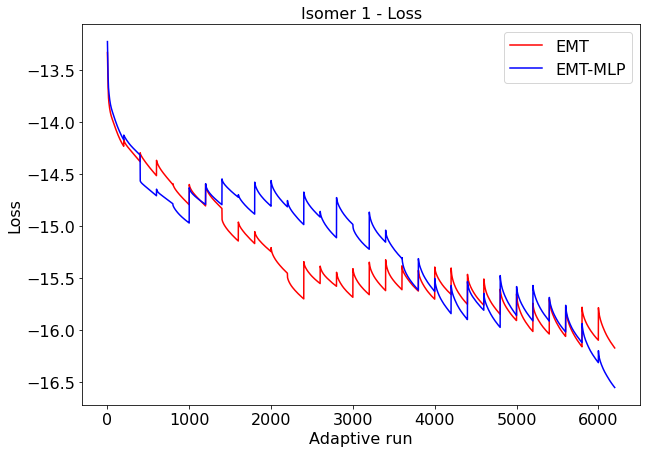

In [17]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

axs = [axs]

#grad_steps = [200, 100]

for i in range(len(losses_emt)):
    set_plot_sequential_data(losses_emt[i], ax=axs[i], color='red', label='EMT', alpha=1, avg=False)
    set_plot_sequential_data(losses_emt_mlp[i], ax=axs[i], color='blue', label='EMT-MLP', alpha=1, avg=False)

    axs[i].set_xlabel('Adaptive run')
    axs[i].set_ylabel('Loss')
    axs[i].set_title(f'Isomer 1 - Loss')

    axs[i].legend()

### 1.c.iii Acceptance ratio

In [19]:
accs_emt = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_emt]
accs_emt_mlp = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_emt_mlp]

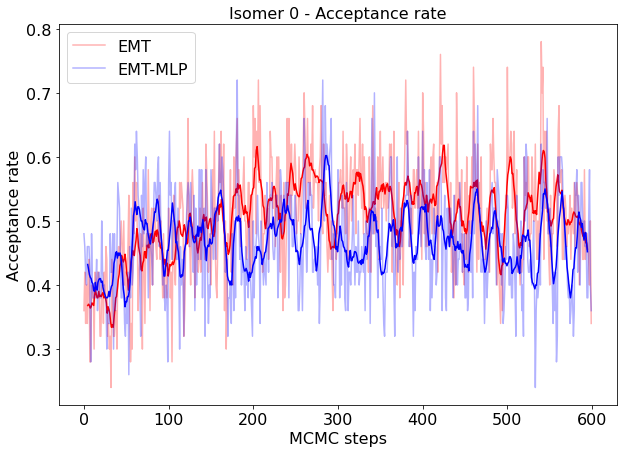

In [21]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

axs = [axs]

for i in range(len(accs_emt_mlp)):

    set_plot_sequential_data(accs_emt[i], ax=axs[i], color='red', label='EMT')
    set_plot_sequential_data(accs_emt_mlp[i], ax=axs[i], color='blue', label='EMT-MLP')

    axs[i].set_xlabel('MCMC steps')
    axs[i].set_ylabel('Acceptance rate')
    axs[i].set_title(f'Isomer {i} - Acceptance rate')

    axs[i].legend()

### 1.c.iv $\hat{R}$ test (Real centered coordinates)

In [22]:
xs_emt = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_emt]
xs_emt_mlp = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_emt_mlp]

In [24]:
rhat_emt = [R_hat(x) for x in xs_emt]
rhat_emt_mlp = [R_hat(x) for x in xs_emt_mlp]

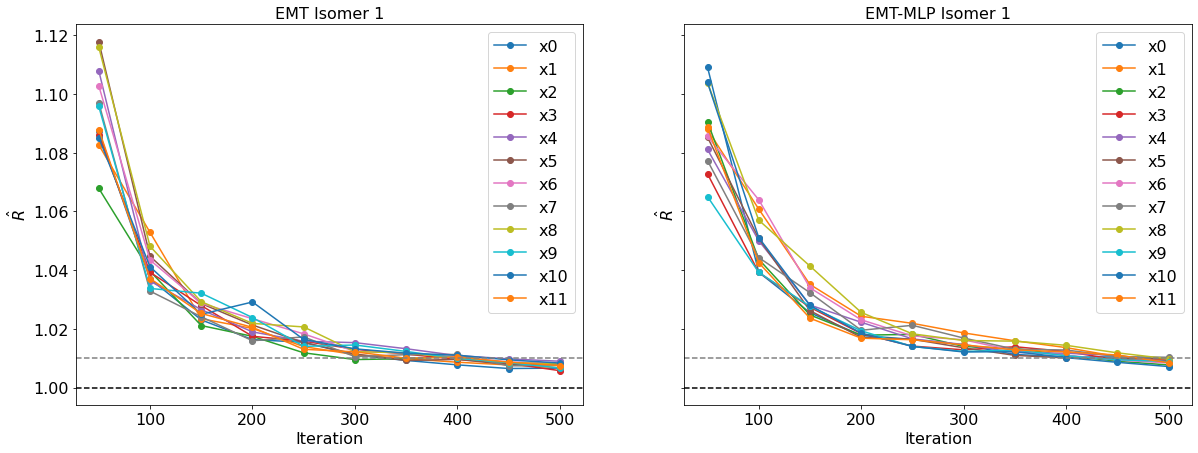

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharex=True, sharey=True)

axs= [axs]

for i in range(len(rhat_emt)):
    axs[i][0].plot(rhat_emt[i][1], rhat_emt[i][0], '-o',  label=rhat_emt[i][2])
    axs[i][0].axhline(1, c='k', ls='--')
    axs[i][0].axhline(1.01, c='grey', ls='--')
    axs[i][0].set_xlabel('Iteration')
    axs[i][0].set_ylabel(r'$\hat{R}$')
    axs[i][0].legend()
    axs[i][0].set_title('EMT Isomer 1')

    axs[i][1].plot(rhat_emt_mlp[i][1], rhat_emt_mlp[i][0], '-o',  label=rhat_emt_mlp[i][2])
    axs[i][1].axhline(1, c='k', ls='--')
    axs[i][1].axhline(1.01, c='grey', ls='--')
    axs[i][1].set_xlabel('Iteration')
    axs[i][1].set_ylabel(r'$\hat{R}$')
    axs[i][1].legend()
    axs[i][1].set_title('EMT-MLP Isomer 1')

### 1.c.v Collective variables

In [30]:
coord_mapping = Coordinates_mapping(etype='emt')

In [31]:
xs_emt = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_emt]
xs_emt_mlp = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_emt_mlp]

In [ ]:
C_emt = []
R_emt = []

for i in range(len(xs_emt)):
    
    C = []
    R = []

    for j in range(xs_emt[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_emt[i][j], isomer=1)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_emt.append(torch.stack(C))
    R_emt.append(torch.stack(R))

In [ ]:
C_emt_mlp = []
R_emt_mlp = []

for i in range(len(xs_emt_mlp)):
    
    C = []
    R = []

    for j in range(xs_emt_mlp[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_emt_mlp[i][j], isomer=1)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_emt_mlp.append(torch.stack(C))
    R_emt_mlp.append(torch.stack(R))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.scatter(C_emt[0].flatten().detach().numpy(), R_emt[0].flatten().detach().numpy(), s=10, c='red', label='EMT')
ax.scatter(C_emt_mlp[0].flatten().detach().numpy(), R_emt_mlp[0].flatten().detach().numpy(), s=10, c='blue', label='EMT-MLP', marker='x', alpha=0.5)

#ax.scatter(C_dft[1].flatten().detach().numpy(), R_dft[1].flatten().detach().numpy(), s=10, c='orange', label='DFT is1')
#ax.scatter(C_mlp[1].flatten().detach().numpy(), R_mlp[1].flatten().detach().numpy(), s=10, c='green', label='MLP is1', marker='x', alpha=0.5)

ax.set_xlabel('Coordination number')
ax.set_ylabel('Radius of gyration')

ax.legend()

### 1.c.vi Energy histograms

In [26]:
us_emt = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_emt]
us_emt_mlp = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_emt_mlp]

In [28]:
dfs = [{'EMT': us_emt[i].flatten().detach(), 
        'EMT-MLP': us_emt_mlp[i].flatten().detach()} for i in range(1)]

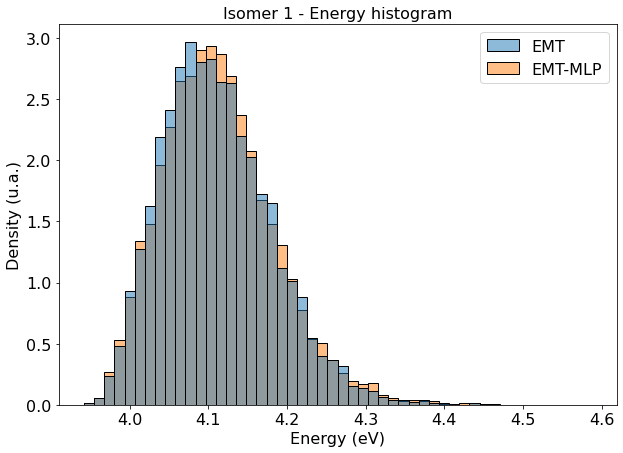

In [29]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

axs = [axs]

for i in range(1):
    plot_energy_histogram(dfs[i], ax=axs[i], bins=50, alpha=0.5)
    axs[i].set_title(f'Isomer 1 - Energy histogram')

## 2. DFT calculations

In [4]:
DFT_DATA_PATH = get_path() + '/andersen/'

### 2.a MD configuration on FES and MLP dataset on FES

In [78]:
# load md data, train and test
xs_flow_dft = [{key: load_csv_file('is{:d}_flow_{:s}.csv'.format(i, key), DFT_DATA_PATH + 'datasets') 
            for key in ['train', 'test']} for i in range(2)]

xs_mlp_dft = [{key: load_csv_file('is{:d}_mlp_{:s}.csv'.format(i, key), DFT_DATA_PATH + 'datasets') 
            for key in ['train', 'test']} for i in range(2)]

In [79]:
# collective variables
cvs_flow_dft = [{key: xs[key][:, -2:] for key in xs.keys()} for xs in xs_flow_dft]
cvs_mlp_dft = [{key: xs[key][:, -2:] for key in xs.keys()} for xs in xs_mlp_dft]

In [80]:
cvs_flow_dft[0]

{'train': tensor([[10.1221,  2.4642],
         [ 9.8397,  2.4740],
         [10.0702,  2.4637],
         ...,
         [ 9.1675,  2.4976],
         [ 9.5649,  2.4933],
         [10.2735,  2.4625]]),
 'test': tensor([[10.6027,  2.4250],
         [ 9.2555,  2.5292],
         [ 9.4343,  2.5093],
         ...,
         [10.1198,  2.4725],
         [10.1634,  2.4553],
         [10.0805,  2.4500]])}

In [81]:
xs_flow_dft = [load_datasets(md='andersen', isomer_id=i, name='flow', real_centered=True, temperature=350)
                for i in range(2)]
xs_mlp_dft = [load_datasets(md='andersen', isomer_id=i, name='mlp', real_centered=True, temperature=350)
                for i in range(2)]

AttributeError: 'list' object has no attribute 'keys'

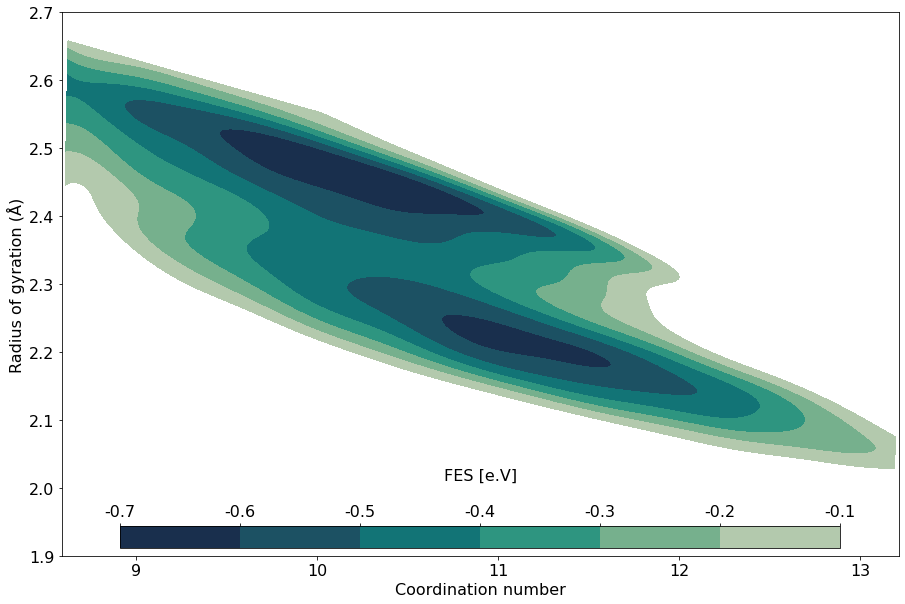

In [89]:
# plot fes

fig, ax = plt.subplots(1, 1, figsize=(15,10))

plot_energy_surface(fig=fig, ax=ax)

for label, cvs in zip(['flow', 'mlp'], [cvs_flow_dft, cvs_mlp_dft]):   
    for key in cvs.keys():
        ax.scatter(cvs[key][:, 0], cvs[key][:, 1], s=5, label=key+' '+label)

#for key in cvs_flow_emt.keys():
#
#    axs[0].scatter(cvs_flow_emt[key][:, 0], cvs_flow_emt[key][:, 1], s=5, label=key)
#
#    for cvs, label in zip([cvs_flow_emt, cvs_mlp_emt], ['flow', 'mlp']):
#        axs[1].scatter(cvs[key][:, 0], cvs[key][:, 1], s=10, label=key +' '+ label)
#
#    axs[1].set_xlabel('Coordination number')
#    axs[1].set_ylabel('Radius of gyration')

ax.legend()
ax.legend()

fig.suptitle('Collective variables on energy surface (EMT)', fontsize=23)

### 2.b MLP model for EMT

In [73]:
dict_mlp_models_dft = [load_pickle_file('dict_mlp_model_is{:d}.pkl'.format(i), DFT_DATA_PATH + 'models')
                        for i in range(2)]

In [84]:
dft_models = [dict_mlp['model'] for dict_mlp in dict_mlp_models_dft]

losses = [{ key: torch.tensor(dict_mlp[key+'_loss']) for key in ['train', 'test']}
                for dict_mlp in dict_mlp_models_dft]

us_flow_pred_dft = [ {key: dft_model(xs[key][:, :12]).detach()
                for key in xs.keys()} for dft_model, xs in zip(dft_models, xs_flow_dft)]

us_mlp_pred_dft = [{key: dft_model(xs[key][:, :12]).detach()
                for key in xs.keys()} for dft_model, xs in zip(dft_models, xs_mlp_dft)]

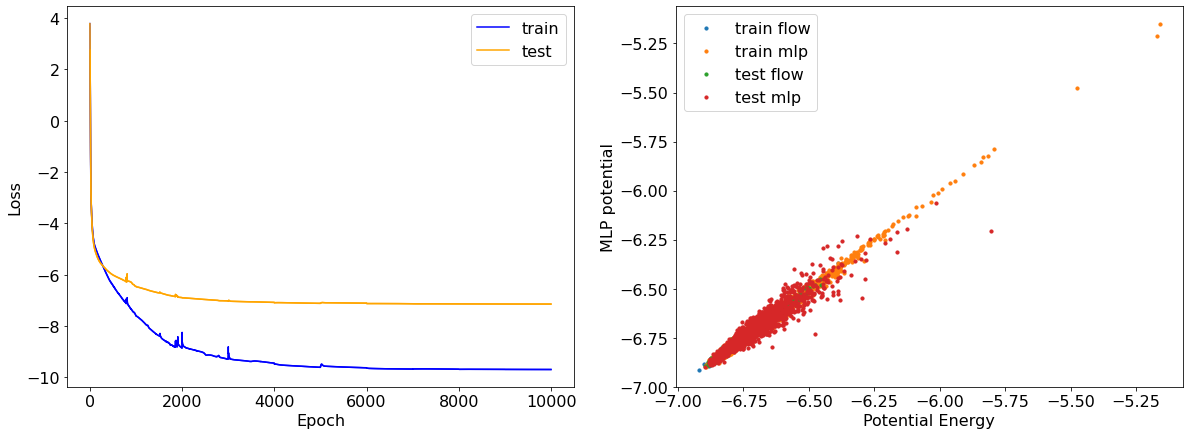

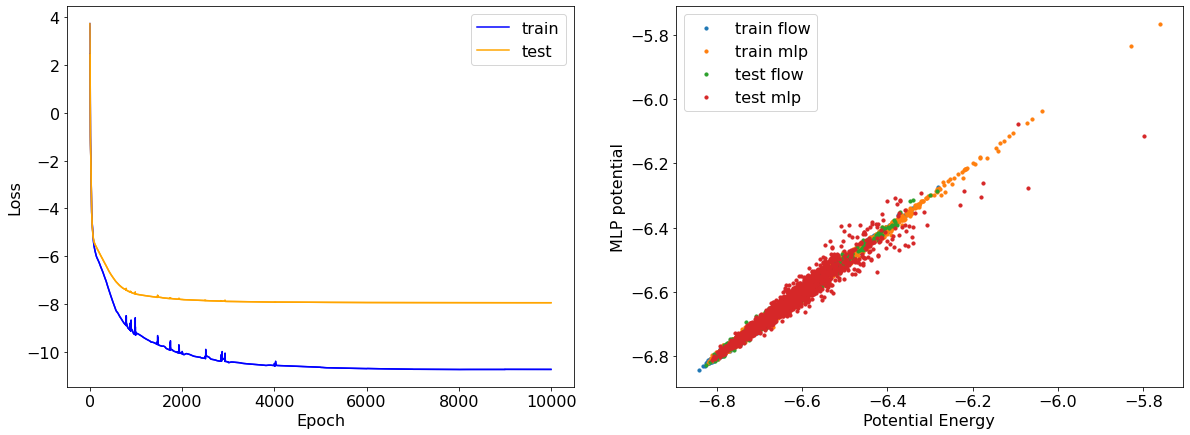

In [88]:
for j in range(2):

    fig, axs = plt.subplots(1, 2, figsize=(20,7))

    colors = ['Blue', 'Orange']


    for i, key in enumerate(us_flow_pred_dft[j].keys()):
        set_plot_sequential_data(losses[j][key].log(), label=key, ax=axs[0], alpha=1, color=colors[i])

    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')

    axs[0].legend()


    for key in us_flow_pred_dft[j].keys():
        for xs, us, label in zip([xs_flow_dft[j], xs_mlp_dft[j]], [us_flow_pred_dft[j], us_mlp_pred_dft[j]], ['flow', 'mlp']):
            axs[1].scatter(xs[key][:, 12].detach(), us[key].flatten().detach(), s=10, label=key +' '+ label)

    axs[1].set_xlabel('Potential Energy')
    axs[1].set_ylabel('MLP potential')

    axs[1].legend()

### 2.c Adaptive DFT with and without MLP

In [5]:
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

In [91]:
adaptives_mcmc_dft = [load_pickle_file(adaptive_file, DFT_SIMS_PATH) for adaptive_file in adaptive_dft_path]
adaptives_mcmc_mlp = [load_pickle_file(adaptive_file, DFT_SIMS_PATH) for adaptive_file in adaptive_mlp_path]

In [92]:
losses_mlp_train = [torch.cat([torch.tensor(adaptives_mcmc_mlp[i]['dict_mlps_training'][j][0]['train_loss'])
                            for j in range(1, len(adaptives_mcmc_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(2)]

losses_mlp_test = [torch.cat([torch.tensor(adaptives_mcmc_mlp[i]['dict_mlps_training'][j][0]['test_loss'])
                            for j in range(1, len(adaptives_mcmc_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(2)]

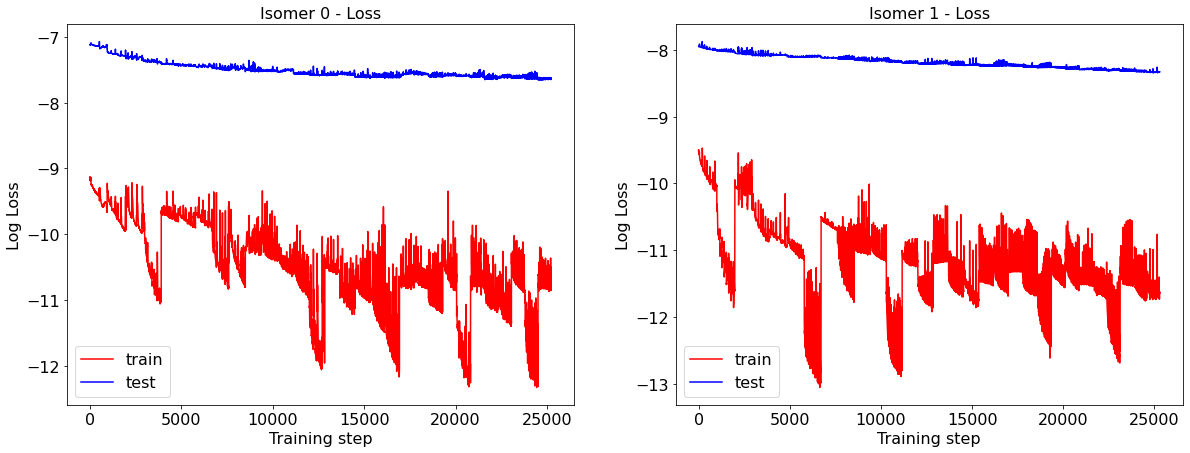

In [93]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(losses_mlp_train)):
    set_plot_sequential_data(torch.log(losses_mlp_train[i]), ax=axs[i], color='red', label='train', alpha=1, avg=False)
    set_plot_sequential_data(torch.log(losses_mlp_test[i]), ax=axs[i], color='blue', label='test', alpha=1, avg=False)

    axs[i].set_xlabel('Training step')
    axs[i].set_ylabel('Log Loss')
    axs[i].set_title(f'Isomer {i} - Loss')

    axs[i].legend()

In [105]:
losses_dft = [torch.cat([adaptives_mcmc_dft[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_dft[i]['dict_flows_training']))
                            ]) 
                            for i in range(2)]
                          
losses_mlp = [torch.cat([adaptives_mcmc_mlp[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_mlp[i]['dict_flows_training']))
                            ])
                            for i in range(2)]

In [113]:
adaptives_mcmc_dft[0]['args']

{'threads': None,
 'process_id': 28685740,
 'random_seed': 48,
 'folder_path': 'andersen',
 'isomer_label': [0],
 'flow_n_iter': 100,
 'flow_learning_rate': 0.0001,
 'flow_batch_size': 500,
 'n_blocks': 4,
 'hidden_dim': 64,
 'hidden_depth': 3,
 'flow_use_scheduler': False,
 'flow_step_scheduler': 100,
 'do_ratios': False,
 'n_prop': 50,
 'mlp_n_iter': 10,
 'mlp_learning_rate': 1e-05,
 'mlp_batch_size': 500,
 'mlp_use_scheduler': False,
 'mlp_step_scheduler': 100,
 'temperature': 350.0,
 'n_runs': 30,
 'n_chains': 50,
 'n_steps': 20,
 'energy_type': 'dft',
 'frac_dft': 0.5,
 'retrain_mlps': False,
 'date_start': '20231010164911',
 'date_end': 20231012104855,
 'algorithm': 'adaptive_sampling.py',
 'time_init': 1696970968.5016038}

In [114]:
adaptives_mcmc_mlp[0]['args']

{'threads': None,
 'process_id': 28706672,
 'random_seed': 42,
 'folder_path': 'andersen',
 'isomer_label': [0],
 'flow_n_iter': 200,
 'flow_learning_rate': 0.0001,
 'flow_batch_size': 1000,
 'n_blocks': 4,
 'hidden_dim': 64,
 'hidden_depth': 3,
 'flow_use_scheduler': False,
 'flow_step_scheduler': 100,
 'do_ratios': False,
 'n_prop': 50,
 'mlp_n_iter': 1000,
 'mlp_learning_rate': 1e-05,
 'mlp_batch_size': 200,
 'mlp_use_scheduler': False,
 'mlp_step_scheduler': 100,
 'temperature': 350.0,
 'n_runs': 30,
 'n_chains': 50,
 'n_steps': 20,
 'energy_type': 'mlp-dft',
 'frac_dft': 0.2,
 'retrain_mlps': True,
 'date_start': '20231011150832',
 'date_end': 20231012054202,
 'algorithm': 'adaptive_sampling.py',
 'time_init': 1697051339.8658314}

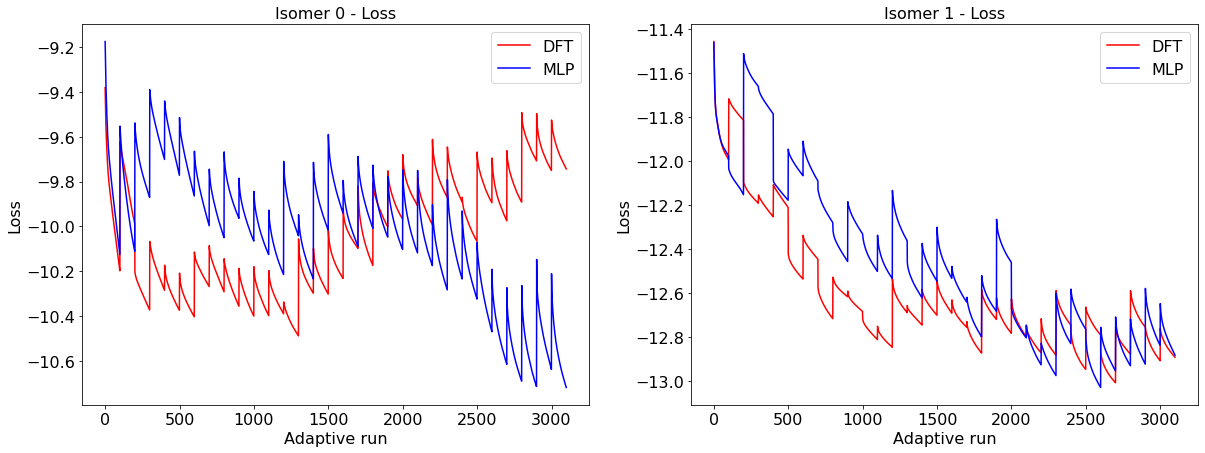

In [118]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

grad_steps = [2, 1]

for i in range(len(losses_dft)):
    set_plot_sequential_data(losses_dft[i], ax=axs[i], color='red', label='DFT', alpha=1, avg=False)
    set_plot_sequential_data(losses_mlp[i][::grad_steps[i]], ax=axs[i], color='blue', label='MLP', alpha=1, avg=False)

    axs[i].set_xlabel('Adaptive run')
    axs[i].set_ylabel('Loss')
    axs[i].set_title(f'Isomer {i} - Loss')

    axs[i].legend()

In [94]:
accs_dft = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_dft]
accs_mlp = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_mlp]

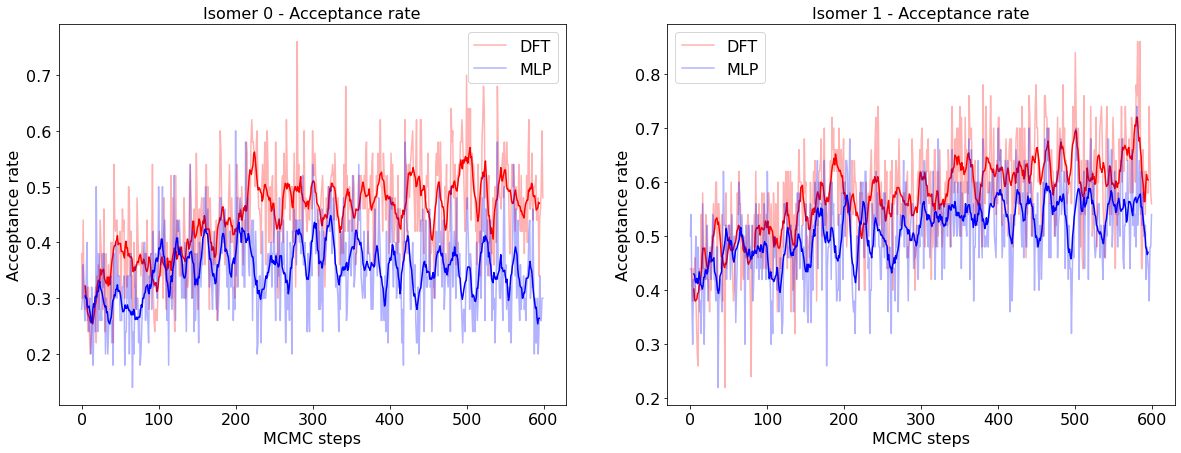

In [95]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(accs_dft)):

    set_plot_sequential_data(accs_dft[i], ax=axs[i], color='red', label='DFT')
    set_plot_sequential_data(accs_mlp[i], ax=axs[i], color='blue', label='MLP')

    axs[i].set_xlabel('MCMC steps')
    axs[i].set_ylabel('Acceptance rate')
    axs[i].set_title(f'Isomer {i} - Acceptance rate')

    axs[i].legend()

In [96]:
xs_dft = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_dft]
xs_mlp = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_mlp]

In [97]:
rhat_dft = [R_hat(x) for x in xs_dft]
rhat_mlp = [R_hat(x) for x in xs_mlp]

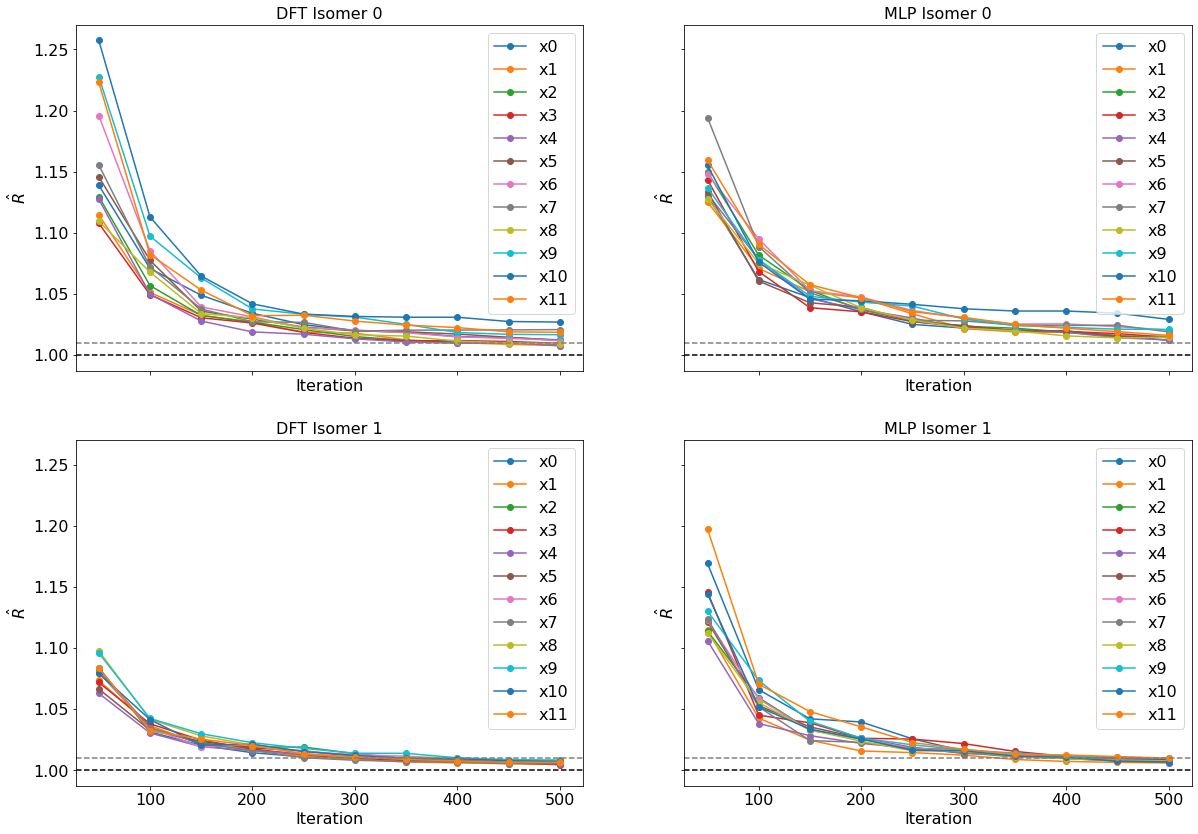

In [98]:
fig, axs = plt.subplots(2, 2, figsize=(20, 14), sharex=True, sharey=True)

for i in range(len(rhat_dft)):
    axs[i][0].plot(rhat_dft[i][1], rhat_dft[i][0], '-o',  label=rhat_dft[i][2])
    axs[i][0].axhline(1, c='k', ls='--')
    axs[i][0].axhline(1.01, c='grey', ls='--')
    axs[i][0].set_xlabel('Iteration')
    axs[i][0].set_ylabel(r'$\hat{R}$')
    axs[i][0].legend()
    axs[i][0].set_title('DFT Isomer {}'.format(i))

    axs[i][1].plot(rhat_mlp[i][1], rhat_mlp[i][0], '-o',  label=rhat_mlp[i][2])
    axs[i][1].axhline(1, c='k', ls='--')
    axs[i][1].axhline(1.01, c='grey', ls='--')
    axs[i][1].set_xlabel('Iteration')
    axs[i][1].set_ylabel(r'$\hat{R}$')
    axs[i][1].legend()
    axs[i][1].set_title('MLP Isomer {}'.format(i))

In [101]:
coord_mapping = Coordinates_mapping(etype='dft')

In [102]:
xs_dft = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_dft]
xs_mlp = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_mlp]

In [103]:
C_dft = []
R_dft = []

for i in range(len(xs_dft)):
    
    C = []
    R = []

    for j in range(xs_dft[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_dft[i][j], isomer=i)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_dft.append(torch.stack(C))
    R_dft.append(torch.stack(R))

In [104]:
C_mlp = []
R_mlp = []

for i in range(len(xs_mlp)):
    
    C = []
    R = []

    for j in range(xs_mlp[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_mlp[i][j], isomer=i)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_mlp.append(torch.stack(C))
    R_mlp.append(torch.stack(R))

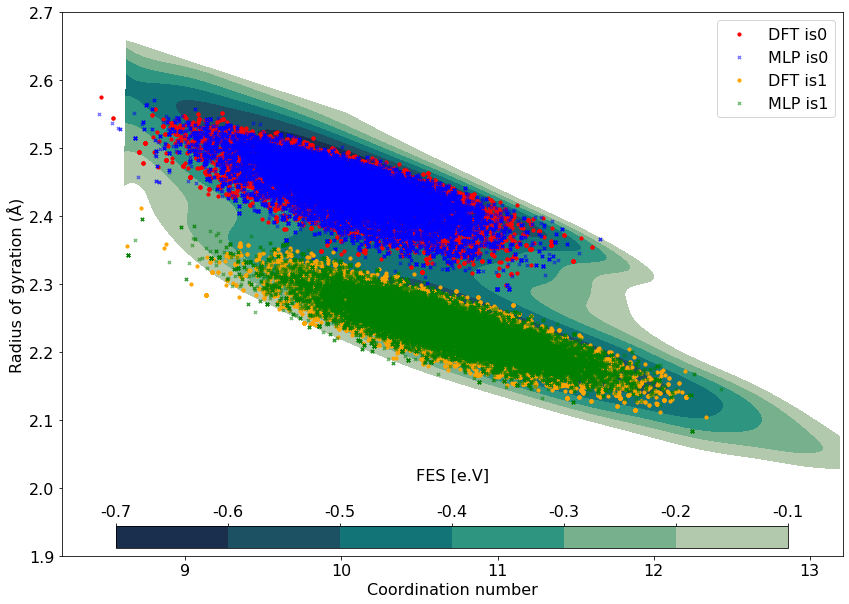

In [112]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

plot_energy_surface(ax=ax, fig=fig)

ax.scatter(C_dft[0].flatten().detach().numpy(), R_dft[0].flatten().detach().numpy(), s=10, c='red', label='DFT is0')
ax.scatter(C_mlp[0].flatten().detach().numpy(), R_mlp[0].flatten().detach().numpy(), s=10, c='blue', label='MLP is0', marker='x', alpha=0.5)

ax.scatter(C_dft[1].flatten().detach().numpy(), R_dft[1].flatten().detach().numpy(), s=10, c='orange', label='DFT is1')
ax.scatter(C_mlp[1].flatten().detach().numpy(), R_mlp[1].flatten().detach().numpy(), s=10, c='green', label='MLP is1', marker='x', alpha=0.5)

ax.legend()

In [109]:
us_dft = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_dft]
us_mlp = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_mlp]

In [110]:
dfs = [{'DFT': us_dft[i].flatten().detach(), 
        'MLP': us_mlp[i].flatten().detach()} for i in range(2)]

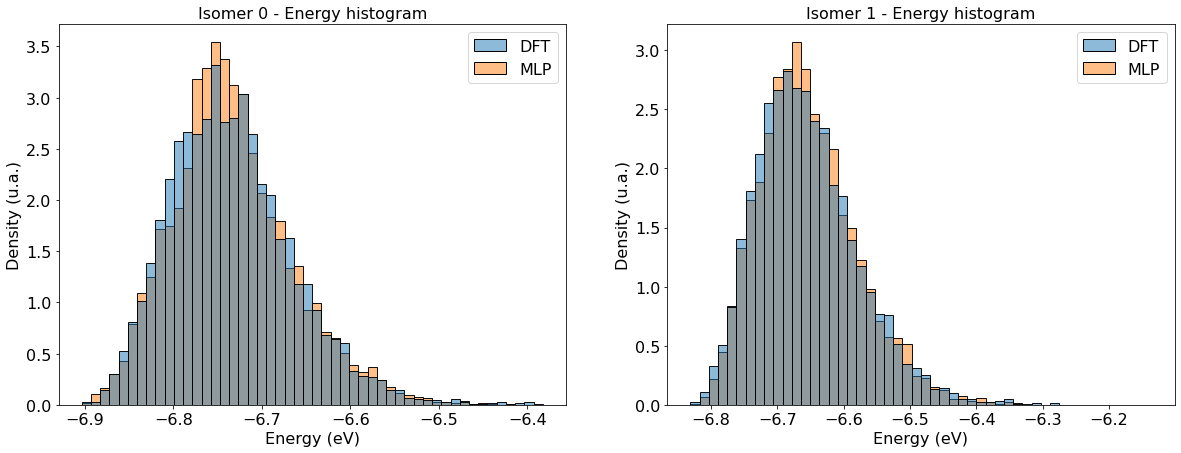

In [111]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(2):
    plot_energy_histogram(dfs[i], ax=axs[i], bins=50, alpha=0.5)
    axs[i].set_title(f'Isomer {i} - Energy histogram')

## 3. Adaptive multimodal sampling

In [174]:
adaptive_multimodal_dft_path = [#'3-adaptive-multimodal/results_adaptive_mixture_28794531/adaptive_sampling_mixture_28794531.pkl',
                                '3-adaptive-multimodal/results_adaptive_mixture_28855880/adaptive_sampling_mixture_28855880.pkl',
                                '4-adaptive-multimodal-mlp/results_adaptive_mixture_28796371/adaptive_sampling_mixture_28796371.pkl']


In [175]:
adaptive_multimodal = [load_pickle_file(adaptive_file, DFT_SIMS_PATH) for adaptive_file in adaptive_multimodal_dft_path]

### 3.a MLP losses

In [176]:
i=1
losses_mlp_train = [torch.cat([torch.tensor(adaptive_multimodal[i]['dict_mlps_training'][j][k]['train_loss'])
                            for j in range(1, len(adaptive_multimodal[i]['dict_mlps_training']))
                            ]) 
                            for k in range(2)]

losses_mlp_test = [torch.cat([torch.tensor(adaptive_multimodal[i]['dict_mlps_training'][j][k]['test_loss'])
                            for j in range(1, len(adaptive_multimodal[i]['dict_mlps_training']))
                            ])
                            for k in range(2)]

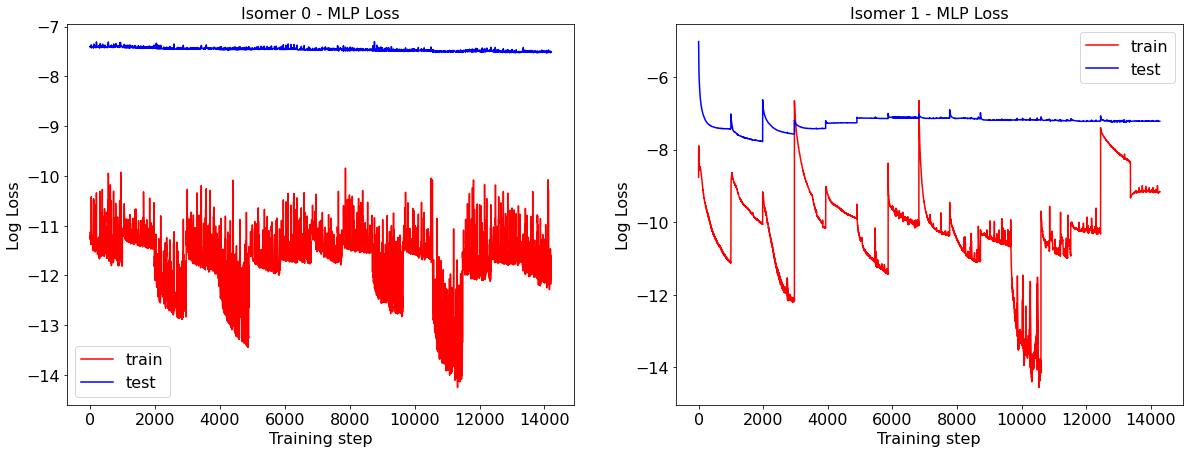

In [177]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(losses_mlp_train)):
    set_plot_sequential_data(torch.log(losses_mlp_train[i]), ax=axs[i], color='red', label='train', alpha=1, avg=False)
    set_plot_sequential_data(torch.log(losses_mlp_test[i]), ax=axs[i], color='blue', label='test', alpha=1, avg=False)

    axs[i].set_xlabel('Training step')
    axs[i].set_ylabel('Log Loss')
    axs[i].set_title(f'Isomer {i} - MLP Loss')

    axs[i].legend()

### 3.b Flow losses

In [178]:
losses_flow = [[torch.cat([adaptive_multimodal[i]['dict_flows_training'][j][k]['losses'][0]
                            for j in range(len(adaptive_multimodal[i]['dict_flows_training']))
                            ]) 
                            for i in range(2)]
                            for k in range(2)]


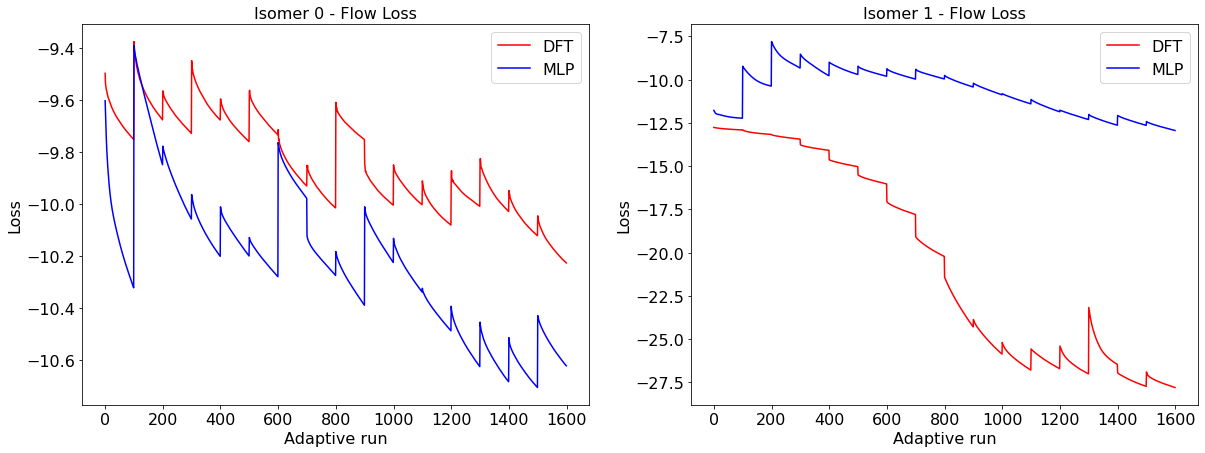

In [179]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

grad_steps = [2, 1]

for i in range(len(losses_flow)):
    set_plot_sequential_data(losses_flow[i][0], ax=axs[i], color='red', label='DFT', alpha=1, avg=False)
    set_plot_sequential_data(losses_flow[i][1], ax=axs[i], color='blue', label='MLP', alpha=1, avg=False)

    #set_plot_sequential_data(losses_flow[i][0][200:][::2], ax=axs[i], color='red', alpha=1, avg=False, init=200)
                             
    axs[i].set_xlabel('Adaptive run')
    axs[i].set_ylabel('Loss')
    axs[i].set_title(f'Isomer {i} - Flow Loss')

    axs[i].legend()

### 3.c Acceptance ratio

In [180]:
accs = [torch.cat(adaptive['accs']).mean(dim=1) for adaptive in adaptive_multimodal]

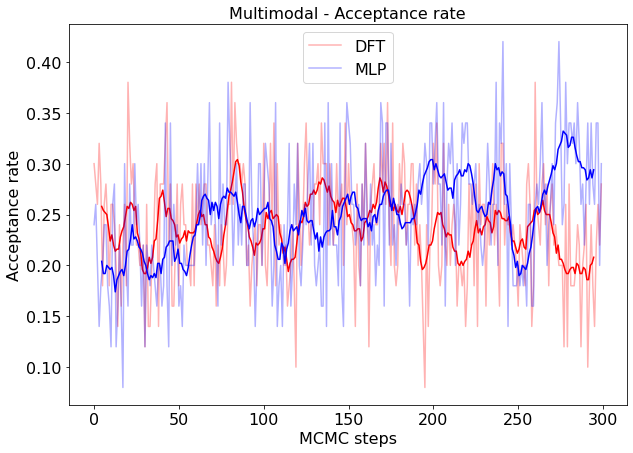

In [181]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

set_plot_sequential_data(accs[0], ax=axs, color='red', label='DFT')
set_plot_sequential_data(accs[1], ax=axs, color='blue', label='MLP')
axs.set_xlabel('MCMC steps')
axs.set_ylabel('Acceptance rate')
axs.set_title(f'Multimodal - Acceptance rate')
axs.legend()

### 3.d Rhat test

In [182]:
xs_dft = [torch.cat(adaptive['xs']).detach().numpy().transpose(1, 0, 2) for adaptive in adaptive_multimodal]

In [183]:
rhat_dft = [R_hat(x) for x in xs_dft]

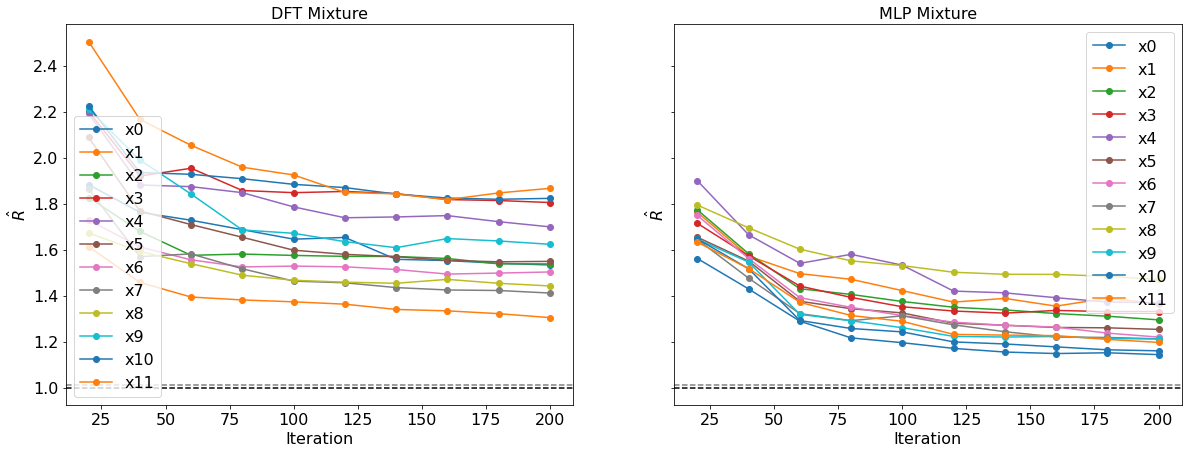

In [184]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharex=True, sharey=True)

labels = ['DFT', 'MLP']

for i in range(len(rhat_dft)):
    axs[i].plot(rhat_dft[i][1], rhat_dft[i][0], '-o',  label=rhat_dft[i][2])
    axs[i].axhline(1, c='k', ls='--')
    axs[i].axhline(1.01, c='grey', ls='--')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel(r'$\hat{R}$')
    axs[i].legend()
    axs[i].set_title('{:s} Mixture'.format(labels[i]))

### 3.e Isomers

In [185]:
isomers = [torch.cat(adaptive_mcmc['isomers']).detach() for adaptive_mcmc in adaptive_multimodal]
accs = [torch.cat(adaptive_mcmc['accs']).detach() for adaptive_mcmc in adaptive_multimodal]

Text(0.5, 1.0, 'MLP')

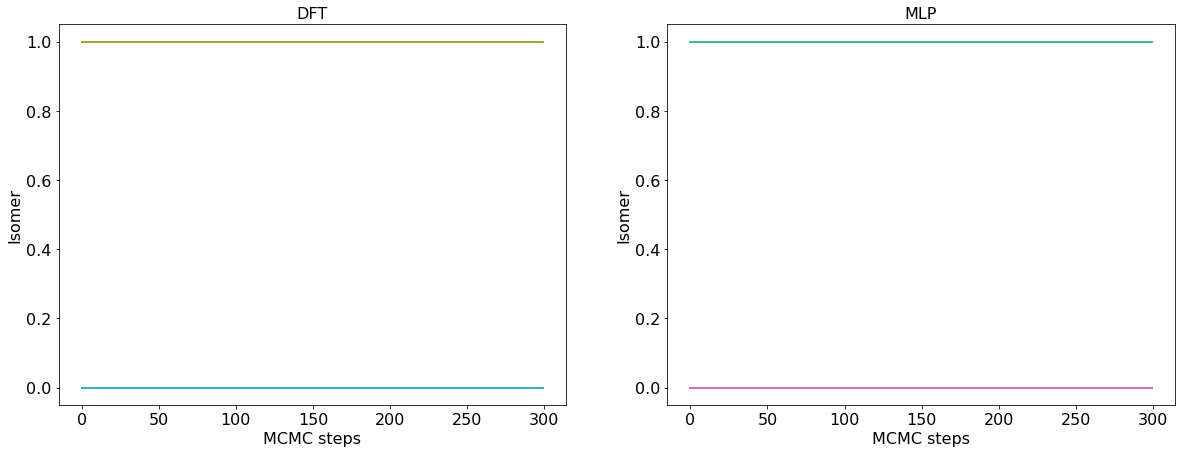

In [186]:
fig, ax = plt.subplots(1, 2, figsize=(20, 7))
ax[0].plot(isomers[0])
ax[0].set_xlabel('MCMC steps')
ax[0].set_ylabel('Isomer')
ax[0].set_title('DFT')

ax[1].plot(isomers[1])
ax[1].set_xlabel('MCMC steps')
ax[1].set_ylabel('Isomer')
ax[1].set_title('MLP')

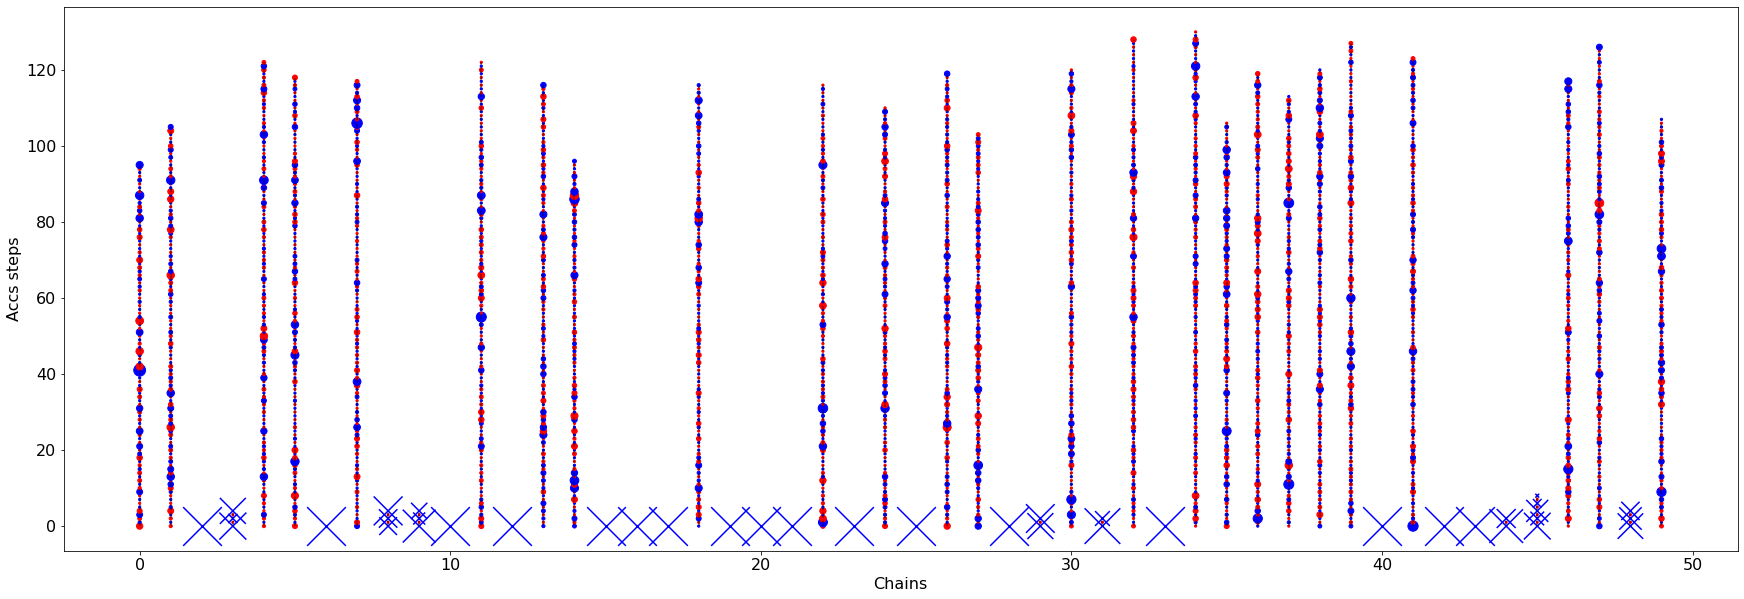

In [187]:
accs = torch.cat(adaptive_multimodal[0]['accs']).T
isomers = torch.cat(adaptive_multimodal[0]['isomers']).T

fig, ax = plt.subplots(1, 1, figsize=(30, 10))

for i in range(accs.shape[0]):

    jumps, counts = accs[i].unique_consecutive(return_counts=True)
    #print(jumps, counts)
    colors_array = []
    for j in range(jumps.shape[0]):
        if jumps[j]==0:
            colors_array.append('blue')
        else:
            colors_array.append('red')
    marker = 'o' if isomers[i].unique()==0 else 'x'
    ax.plot(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), 'k--', alpha=0.4)
    ax.scatter(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), s=counts*5, color=colors_array, marker=marker)
    ax.set_xlabel('Chains')
    ax.set_ylabel('Accs steps')

In [188]:
#accs_isomer = [(acc.unique_consecutive(), isomer.unique_consecutive()) for acc, isomer in zip(accs[0].T, isomers[0].T)]

In [189]:
#n_chain = 6
#fig, ax = plt.subplots(1, 2, figsize=(20, 7))
#ax[0].plot(accs[0][:, n_chain], label = 'Chain {:d}'.format(n_chain))
#ax[0].set_xlabel('MCMC steps')
#ax[0].set_ylabel('Acc')
#ax[0].set_title('DFT')
#
#ax[1].plot(accs[1][:, n_chain], label = 'Chain {:d}'.format(n_chain))
#ax[1].set_xlabel('MCMC steps')
#ax[1].set_ylabel('Acc')
#ax[1].set_title('MLP')

### 3.f Energies

Text(0.5, 1.0, 'Energy histogram')

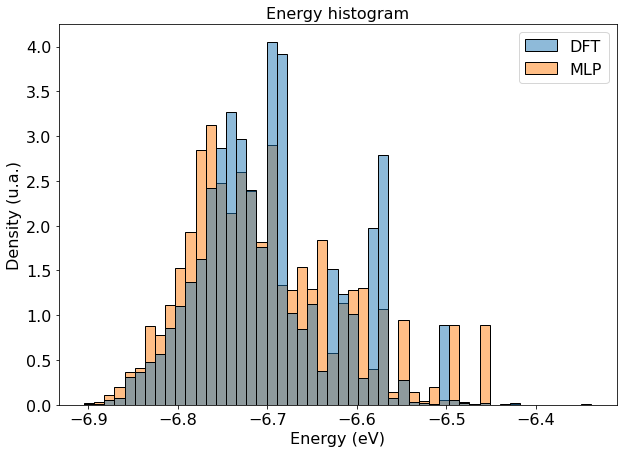

In [190]:
us = {label: torch.cat(adaptive['us']).flatten().detach() for adaptive, label in zip(adaptive_multimodal, ['DFT', 'MLP'])}

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

plot_energy_histogram(us, ax=axs, bins=50, alpha=0.5)
axs.set_title(f'Energy histogram')


## 4. Metropolis hastings Mixture

In [191]:
mcmc_path = '5-multimodal/results_multimodal_sampling_mixture_28898240/mixture_mcmc_dic_28898240.pkl'
mcmc = load_pickle_file(mcmc_path, DFT_SIMS_PATH)

### 4.a Acceptance ratio

In [192]:
accs_mcmc = mcmc['accs'].mean(dim=1)

Text(0, 0.5, 'Acceptance rate')

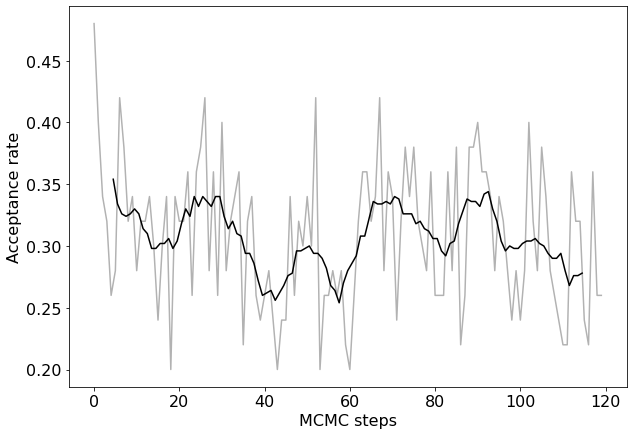

In [193]:

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

set_plot_sequential_data(accs_mcmc, ax=ax)
ax.set_xlabel('MCMC steps')
ax.set_ylabel('Acceptance rate')

### 4.b Collective variables

In [194]:
coord_mapping = Coordinates_mapping(etype='dft')

xs = mcmc['xs']
xs_flatten = xs.reshape(-1, 12)

isomers_mask = mcmc['isomers'].reshape(-1, 1)

xs_is0 = []
xs_is1 = []

for isomer, x in zip(isomers_mask, xs_flatten):
    if isomer==0:
        xs_is0.append(x)
    else:
        xs_is1.append(x)

xs_is0 = torch.stack(xs_is0) 
xs_is1 = torch.stack(xs_is1) 

In [195]:
cvs_is0 = coord_mapping.get_collective_variables_from_real_centered(xs_is0, isomer=0)

In [196]:
cvs_is1 = coord_mapping.get_collective_variables_from_real_centered(xs_is1, isomer=1)

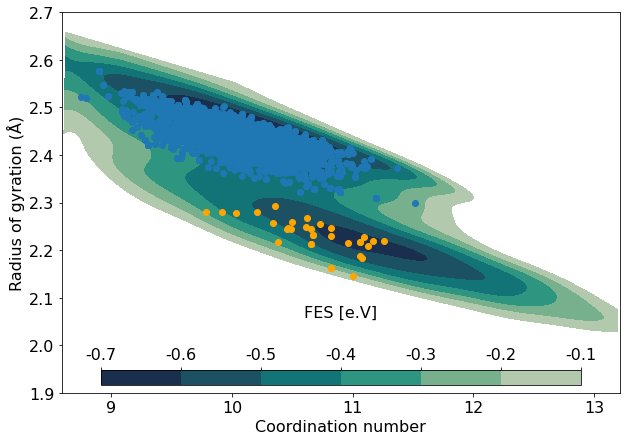

In [197]:
fig, ax = plt.subplots(1,1, figsize=(10, 7))

plot_energy_surface(fig=fig, ax=ax)

ax.scatter(cvs_is0[:, 0], cvs_is0[:, 1], )
ax.scatter(cvs_is1[:, 0], cvs_is1[:, 1], c='orange')

### 4.c Jumps between isomers

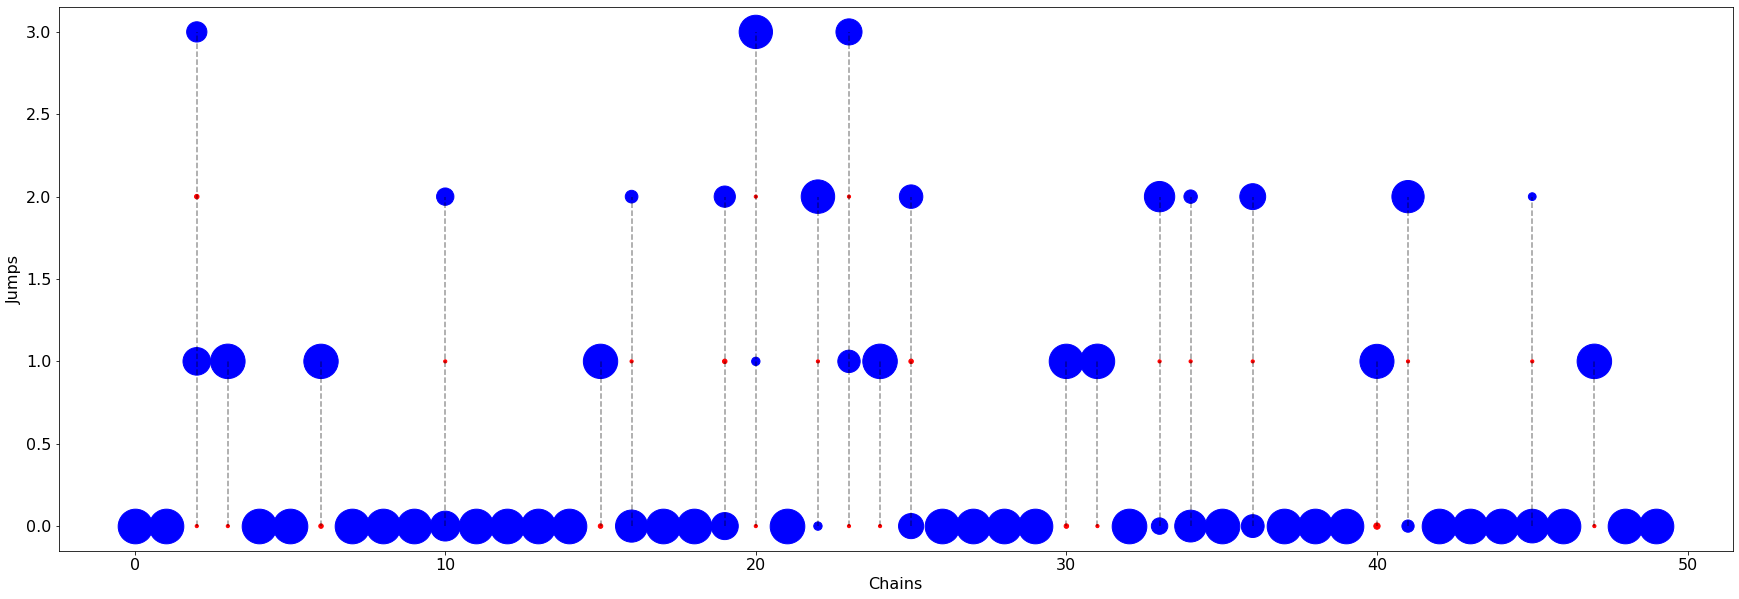

In [201]:
isomers = mcmc['isomers'].T

fig, ax = plt.subplots(1, 1, figsize=(30, 10))

for i in range(isomers.shape[0]):

    jumps, counts = isomers[i].unique_consecutive(return_counts=True)
    #print(jumps, counts)
    colors_array = []
    for j in range(jumps.shape[0]):
        if jumps[j]==0:
            colors_array.append('blue')
        else:
            colors_array.append('red')
    #print(colors_array)
    ax.plot(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), 'k--', alpha=0.4)
    ax.scatter(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), s=counts*10, color=colors_array)
    ax.set_xlabel('Chains')
    ax.set_ylabel('Jumps')

### 4.d Rhat test

In [202]:
xs = mcmc["xs"].detach().numpy().transpose(1, 0, 2)
isomers = mcmc["isomers"].detach().numpy().transpose(1, 0)

coord_mapping = Coordinates_mapping()

zmat = torch.zeros(xs.shape)

for i in range(xs.shape[1]):
    for j in range(xs.shape[0]):
        zmat[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs[j, i]).reshape(1, -1), 
                                                                    isomer=isomers[j, i])[0]
zmat = zmat.clone().detach().numpy()

In [203]:
rhat_s_xs = R_hat(xs)
rhat_s_zmat = R_hat(zmat)

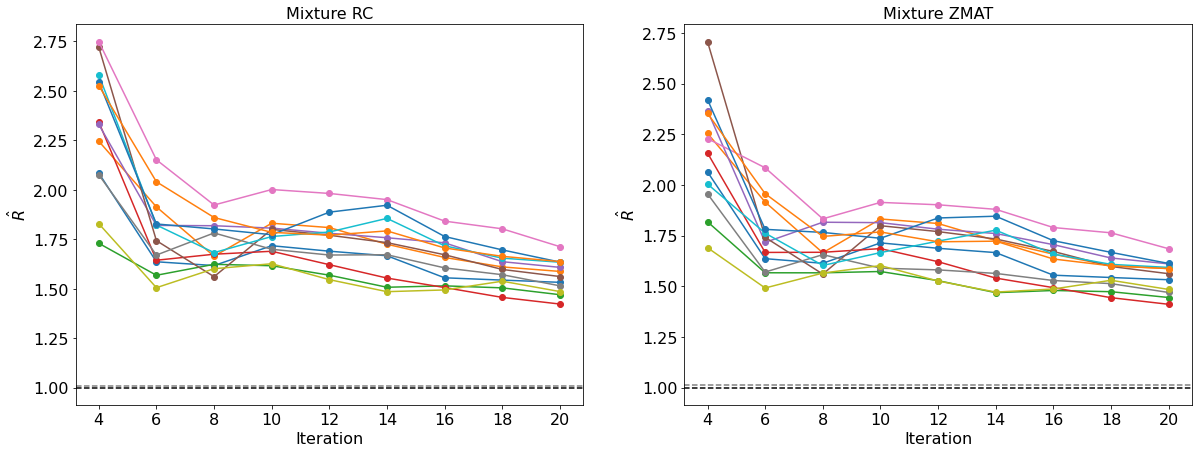

In [204]:
rhat_s = [rhat_s_xs, rhat_s_zmat]
coordinates = ["RC", "ZMAT"]

fig, axs = plt.subplots(1, len(rhat_s), figsize=(20, 7),)

for j in range(len(rhat_s)):
        
    axs[j].plot(rhat_s[j][1], rhat_s[j][0], '-o',  label=rhat_s[j][2])
    axs[j].axhline(1, c='k', ls='--')
    axs[j].axhline(1.01, c='grey', ls='--')
    axs[j].set_xlabel('Iteration')
    axs[j].set_ylabel(r'$\hat{R}$')
    #axs[j][i].legend()
    axs[j].set_title('Mixture {}'.format(coordinates[j]))

### 4.e Energies

Text(0.5, 1.0, 'Energy histogram')

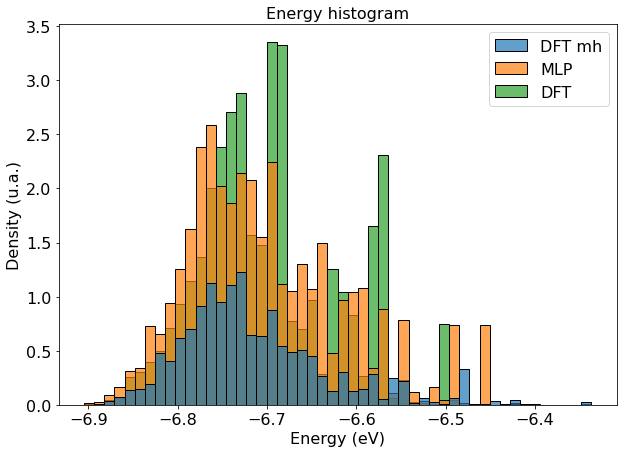

In [250]:
us['DFT mh'] = mcmc['us'].flatten().detach()

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

plot_energy_histogram(us, ax=axs, bins=50, alpha=0.7, hue_order=['DFT mh', 'MLP', 'DFT'])
axs.set_title(f'Energy histogram')

### 4.e Populations

Text(0, 0.5, 'Population is1')

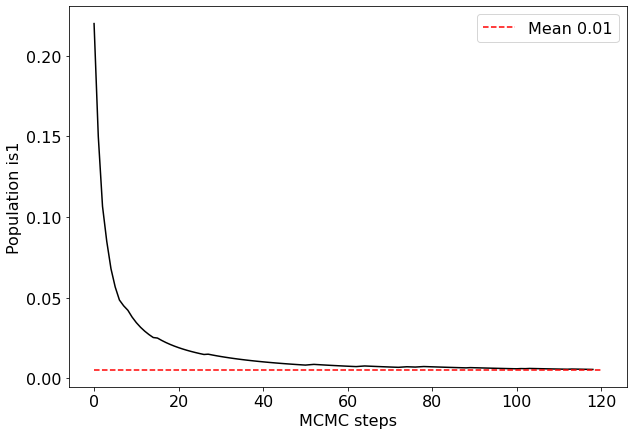

In [241]:
isomers = mcmc['isomers']

population_is1 = torch.stack([isomers[:i].mean() for i in range(1, isomers.shape[0])])

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

set_plot_sequential_data(torch.tensor(population_is1).flatten().detach(), ax=axs, avg=False, alpha=1)
axs.hlines(isomers.mean().detach(), 0, 120, colors='r', linestyles='dashed', label='Mean {:.2f}'.format(isomers.mean().detach()))

axs.legend()
axs.set_xlabel('MCMC steps')
axs.set_ylabel('Population is1')